# ChestX-ray14 · EfficientNet-B1 · PyTorch replication (v2)

Replicating **Kufel et al. (2023)**, *J. Pers. Med.* 13, 1426 — target mean AUC **0.843**.

Stack: PyTorch + timm + albumentations + OpenCV. No torchvision.

---

### What changed from v1

| Area | v1 | v2 |
|---|---|---|
| Backbone | `efficientnet_b1_pruned` (accident) | `tf_efficientnet_b1.ns_jft_in1k`, unpruned |
| BatchNorm | denormal `running_var` crashed it | auto-repaired at build time |
| Source images | 224px Kaggle mirror | **genuine 1024px NIH, resized by us to 240** |
| Resolution | 224 | **240** (B1 design resolution) |
| Head | no dropout | dropout 0.3 ×2 |
| Optimizer | Adam, flat 1e-4 | AdamW, backbone 1e-5 / head 5e-4 |
| Schedule | none | cosine annealing → 1e-7 |
| Augmentation | paper's (weak) | stronger (documented deviation) |
| Patience | 5 | **7** |
| Crash recovery | none | **auto-resume from `last.pt`** |
| Outputs | AUC only | AUC + **ROC curves** + sensitivity/specificity/F1/AUPRC |

### Before running

| Setting | Value |
|---|---|
| Accelerator | GPU T4 x2 or P100 |
| Internet | **ON** |
| Data | `nih-chest-xrays/data` (the full 45 GB set) |

### Run order

Cells 1–15 are setup (~20 min, mostly the pre-resize). Cell 16 is the gate — it must
print a loss near 0.6931. Cell 19 is the ~3 hour training run.

## Cell 1 · GPU check

In [1]:
import torch, sys

print("python :", sys.version.split()[0])
print("torch  :", torch.__version__)
print("cuda   :", torch.cuda.is_available())
if not torch.cuda.is_available():
    raise SystemExit("NO GPU. Settings -> Accelerator -> GPU T4 x2")
print("device :", torch.cuda.get_device_name(0))
print("memory :", f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

python : 3.12.13
torch  : 2.10.0+cu128
cuda   : True
device : Tesla T4
memory : 15.6 GB


## Cell 2 · Imports

In [2]:
try:
    import timm, albumentations as A
except ImportError:
    !pip install -q timm albumentations
    import timm, albumentations as A

import json, os, pickle, random, shutil, time
from dataclasses import dataclass, asdict
from multiprocessing import Pool
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import (roc_auc_score, roc_curve, average_precision_score,
                             precision_recall_fscore_support)
from torch.utils.data import DataLoader, Dataset

cv2.setNumThreads(0)
print("timm:", timm.__version__, "| albumentations:", A.__version__)

timm: 1.0.26 | albumentations: 2.0.8


## Cell 3 · Path check

Deliberately does not walk the filesystem — a recursive glob over 112,120 files costs
several minutes and you already know where the data lives. If either assert fails, fix
the paths in Cell 4.

In [3]:
for p in ["/kaggle/input/datasets/nih-chest-xrays/data/Data_Entry_2017.csv",
          "/kaggle/input/datasets/nih-chest-xrays/data/images_001"]:
    print(f"{'OK ' if Path(p).exists() else 'MISSING'}  {p}")

OK   /kaggle/input/datasets/nih-chest-xrays/data/Data_Entry_2017.csv
OK   /kaggle/input/datasets/nih-chest-xrays/data/images_001


## Cell 4 · Config

Every field marked `DEVIATION` differs from the paper on purpose. Every field marked
`[ASSUMPTION]` fills a gap the paper left unspecified. Both lists belong in your write-up —
this cell writes them to `config.json` so the record is automatic.

In [4]:
PATHOLOGIES = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
    "Mass", "Nodule", "Pneumonia", "Pneumothorax",
    "Consolidation", "Edema", "Emphysema", "Fibrosis",
    "Pleural_Thickening", "Hernia",
]
N_CLASSES = len(PATHOLOGIES)

PAPER_AUC = {
    "Atelectasis": 0.817, "Cardiomegaly": 0.911, "Effusion": 0.879,
    "Infiltration": 0.716, "Mass": 0.853, "Nodule": 0.771,
    "Pneumonia": 0.769, "Pneumothorax": 0.898, "Consolidation": 0.815,
    "Edema": 0.908, "Emphysema": 0.935, "Fibrosis": 0.824,
    "Pleural_Thickening": 0.812, "Hernia": 0.890,
}
PAPER_MEAN_AUC = 0.843


@dataclass
class Config:
    # ---- paths (resolved automatically below) --------------------------
    csv_path: str    = ""
    src_root: str    = ""
    cache_root: str  = "/kaggle/working/img240"
    out_dir: str     = "/kaggle/working/artifacts"

    # ---- data ---------------------------------------------------------
    img_size: int     = 240    # B1 design resolution (compound scaling)
    use_cache: bool   = True   # pre-resize 1024 -> 240 once, then train fast
    split_seed: int   = 97     # DEVIATION: paper used 2137; 97 balances rare labels
    train_frac: float = 0.70
    val_frac: float   = 0.10   # DEVIATION: paper had no validation set at all

    # ---- model --------------------------------------------------------
    backbone: str    = "tf_efficientnet_b1.ns_jft_in1k"
    pretrained: bool = True
    head_dim_1: int  = 512     # [ASSUMPTION] paper shows Dense, gives no width
    head_dim_2: int  = 256     # [ASSUMPTION]
    dropout: float   = 0.3     # DEVIATION: paper's head has no dropout

    # ---- optimisation -------------------------------------------------
    optimizer_name: str      = "AdamW"   # DEVIATION: paper used Adam
    backbone_lr: float       = 1e-5      # discriminative: gentle on pretrained
    head_lr: float           = 5e-4      # discriminative: fast on random head
    weight_decay: float      = 1e-4
    scheduler: str           = "cosine"  # DEVIATION: paper specifies no schedule
    scheduler_eta_min: float = 1e-7
    batch_size: int          = 40        # [ASSUMPTION]
    epochs: int              = 30        # [ASSUMPTION] cap
    patience: int            = 7         # stop after 7 epochs with no gain
    num_workers: int         = 3         # 3 not 4: v1 workers were OOM-killed
    amp: bool                = True
    pos_weight: bool         = False     # paper = plain BCE
    augmentation: str        = "strong"  # DEVIATION: paper's is much weaker

    seed: int = 42


cfg = Config()

# Auto-locate the data. Kaggle nests mounts differently depending on how
# the dataset was attached, so don't trust a hardcoded path.
_hits = list(Path("/kaggle/input").rglob("Data_Entry_2017.csv"))
if not _hits:
    raise SystemExit("Data_Entry_2017.csv not found. Attach the "
                     "'NIH Chest X-rays' dataset under Add Data.")
_csv = _hits[0]
cfg.csv_path = str(_csv)
cfg.src_root = str(_csv.parent)

_imgdirs = list(Path(cfg.src_root).glob("images_*"))
assert _imgdirs, f"no images_* folders under {cfg.src_root}"

print(f"csv       : {cfg.csv_path}")
print(f"src_root  : {cfg.src_root}")
print(f"image dirs: {len(_imgdirs)} (expect 12)")

OUT = Path(cfg.out_dir); OUT.mkdir(parents=True, exist_ok=True)
(OUT / "config.json").write_text(json.dumps(asdict(cfg), indent=2))
print("\n" + json.dumps(asdict(cfg), indent=2))

csv       : /kaggle/input/datasets/nih-chest-xrays/data/Data_Entry_2017.csv
src_root  : /kaggle/input/datasets/nih-chest-xrays/data
image dirs: 12 (expect 12)

{
  "csv_path": "/kaggle/input/datasets/nih-chest-xrays/data/Data_Entry_2017.csv",
  "src_root": "/kaggle/input/datasets/nih-chest-xrays/data",
  "cache_root": "/kaggle/working/img240",
  "out_dir": "/kaggle/working/artifacts",
  "img_size": 240,
  "use_cache": true,
  "split_seed": 97,
  "train_frac": 0.7,
  "val_frac": 0.1,
  "backbone": "tf_efficientnet_b1.ns_jft_in1k",
  "pretrained": true,
  "head_dim_1": 512,
  "head_dim_2": 256,
  "dropout": 0.3,
  "optimizer_name": "AdamW",
  "backbone_lr": 1e-05,
  "head_lr": 0.0005,
  "weight_decay": 0.0001,
  "scheduler": "cosine",
  "scheduler_eta_min": 1e-07,
  "batch_size": 40,
  "epochs": 30,
  "patience": 7,
  "num_workers": 3,
  "amp": true,
  "pos_weight": false,
  "augmentation": "strong",
  "seed": 42
}


## Cell 5 · Seeding

In [5]:
def seed_everything(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything(cfg.seed)
device = torch.device("cuda")
print("seeded | device:", device)

seeded | device: cuda


## Cell 6 · Labels

Pipe-separated text → 14-column multi-hot matrix. `"No Finding"` is not a 15th class;
it's a row of all zeros.

Verify against the paper's Table 1 — **Hernia must be exactly 227**.

In [6]:
df_raw = pd.read_csv(cfg.csv_path)
df_raw.columns = [c.strip() for c in df_raw.columns]

label_sets = df_raw["Finding Labels"].str.split("|").apply(set)
df = df_raw[["Image Index", "Patient ID"]].copy()
for p in PATHOLOGIES:
    csv_name = p.replace("_", " ")
    df[p] = label_sets.apply(lambda s, a=csv_name, b=p: int(a in s or b in s))
df["n_labels"] = df[PATHOLOGIES].sum(axis=1)

print(f"images          : {len(df):,}")
print(f"unique patients : {df['Patient ID'].nunique():,}   (paper claims 32,717 - wrong)")
print(f"no-finding rows : {(df.n_labels==0).sum():,} ({100*(df.n_labels==0).mean():.2f}%)")
print("\nprevalence:")
print(pd.DataFrame({"count": df[PATHOLOGIES].sum(),
                    "pct": 100*df[PATHOLOGIES].mean()})
      .sort_values("count", ascending=False)
      .to_string(float_format=lambda x: f"{x:.2f}"))

images          : 112,120
unique patients : 30,805   (paper claims 32,717 - wrong)
no-finding rows : 60,361 (53.84%)

prevalence:
                    count   pct
Infiltration        19894 17.74
Effusion            13317 11.88
Atelectasis         11559 10.31
Nodule               6331  5.65
Mass                 5782  5.16
Pneumothorax         5302  4.73
Consolidation        4667  4.16
Pleural_Thickening   3385  3.02
Cardiomegaly         2776  2.48
Emphysema            2516  2.24
Edema                2303  2.05
Fibrosis             1686  1.50
Pneumonia            1431  1.28
Hernia                227  0.20


## Cell 7 · Patient-wise split

Randomise at the **patient** level. One patient contributes ~3.6 images; splitting by
image puts the same ribcage in train and test and inflates AUC by several points.

The assertion is non-negotiable.

In [7]:
def patient_split(frame, seed, train_frac, val_frac):
    pids = np.random.default_rng(seed).permutation(frame["Patient ID"].unique())
    n = len(pids); n_tr = int(round(train_frac*n)); n_va = int(round(val_frac*n))
    a = {}
    for pid in pids[:n_tr]:            a[pid] = "train"
    for pid in pids[n_tr:n_tr+n_va]:   a[pid] = "val"
    for pid in pids[n_tr+n_va:]:       a[pid] = "test"
    return frame["Patient ID"].map(a)


df["split"] = patient_split(df, cfg.split_seed, cfg.train_frac, cfg.val_frac)

overlap = (df.groupby("Patient ID")["split"].nunique() > 1).sum()
assert overlap == 0, f"LEAKAGE: {overlap} patients span splits"
print("leakage check PASSED\n")

print(df["split"].value_counts().to_string())
print("\nprevalence by split (%):")
print((100*df.groupby("split")[PATHOLOGIES].mean()).T
      .to_string(float_format=lambda x: f"{x:.2f}"))
df.to_csv(OUT / "labels.csv", index=False)

leakage check PASSED

split
train    78185
test     22798
val      11137

prevalence by split (%):
split               test  train   val
Atelectasis        10.26  10.27 10.69
Cardiomegaly        2.36   2.49  2.59
Effusion           12.39  11.69 12.17
Infiltration       17.86  17.64 18.26
Mass                4.82   5.26  5.16
Nodule              6.04   5.56  5.46
Pneumonia           1.25   1.29  1.25
Pneumothorax        4.97   4.69  4.52
Consolidation       3.97   4.25  3.93
Edema               1.97   2.11  1.83
Emphysema           2.38   2.21  2.18
Fibrosis            1.43   1.55  1.36
Pleural_Thickening  2.85   3.11  2.73
Hernia              0.20   0.20  0.22


## Cell 8 · Index the 1024px source files

Cached to `index_src.pkl` so a kernel restart doesn't cost another two minutes.

In [8]:
idx_cache = OUT / "index_src.pkl"

if idx_cache.exists():
    SRC_INDEX = {k: Path(v) for k, v in pickle.loads(idx_cache.read_bytes()).items()}
    print(f"loaded {len(SRC_INDEX):,} paths from cache")
else:
    t0 = time.time()
    SRC_INDEX = {}
    for p in Path(cfg.src_root).rglob("*.png"):
        SRC_INDEX.setdefault(p.name, p)
    idx_cache.write_bytes(pickle.dumps({k: str(v) for k, v in SRC_INDEX.items()}))
    print(f"indexed {len(SRC_INDEX):,} images in {time.time()-t0:.0f}s")

before = len(df)
df = df[df["Image Index"].isin(SRC_INDEX)].reset_index(drop=True)
print(f"matched {len(df):,} / {before:,}")
print("example:", SRC_INDEX[df['Image Index'].iloc[0]])

indexed 112,120 images in 40s
matched 112,120 / 112,120
example: /kaggle/input/datasets/nih-chest-xrays/data/images_001/images/00000001_000.png


## Cell 9 · Pre-resize 1024 → 240  *(~15 min, once)*

Reads the genuine NIH originals and downsamples with `INTER_AREA` — proper area-averaging,
which avoids the aliasing that nearest-neighbour introduces on fine lung texture.

**Why do this at all?** Decoding 1024×1024 PNGs every epoch caps you at ~60 img/s on
Kaggle's 4 vCPUs (~22 min/epoch, ~10 h total). Resizing once gets you 200+ img/s
(~7 min/epoch). Same source data, same pixels the model would have seen — you just pay
the decode cost once instead of 30 times.

Set `cfg.use_cache = False` in Cell 4 to skip this and read originals directly.

In [9]:
from concurrent.futures import ThreadPoolExecutor

CACHE = Path(cfg.cache_root)

if cfg.use_cache:
    CACHE.mkdir(parents=True, exist_ok=True)
    todo = [(str(SRC_INDEX[n]), str(CACHE / n))
            for n in df["Image Index"] if not (CACHE / n).exists()]
    print(f"{len(df)-len(todo):,} already cached | {len(todo):,} to build")

    def resize_one(job):
        src, dst = job
        img = cv2.imread(src, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return 0
        img = cv2.resize(img, (cfg.img_size, cfg.img_size),
                         interpolation=cv2.INTER_AREA)
        cv2.imwrite(dst, img, [cv2.IMWRITE_PNG_COMPRESSION, 3])
        return 1

    if todo:
        t0, done, failed = time.time(), 0, 0
        with ThreadPoolExecutor(max_workers=8) as ex:
            for r in ex.map(resize_one, todo):
                done += 1
                failed += (r == 0)
                if done % 10000 == 0:
                    rate = done / max(time.time()-t0, 1e-9)
                    print(f"  {done:,}/{len(todo):,}  {rate:.0f} img/s  "
                          f"eta {(len(todo)-done)/max(rate,1e-9)/60:.0f} min", flush=True)
        print(f"done in {(time.time()-t0)/60:.1f} min | unreadable: {failed}")

    INDEX = {n: CACHE / n for n in df["Image Index"] if (CACHE / n).exists()}
    df = df[df["Image Index"].isin(INDEX)].reset_index(drop=True)
    print(f"\ncache: {len(INDEX):,} images, "
          f"{sum(f.stat().st_size for f in CACHE.iterdir())/1e9:.2f} GB")
else:
    INDEX = SRC_INDEX
    print("using 1024px originals directly (slow)")

0 already cached | 112,120 to build


libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


  10,000/112,120  154 img/s  eta 11 min


libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


  20,000/112,120  155 img/s  eta 10 min
  30,000/112,120  155 img/s  eta 9 min
  40,000/112,120  156 img/s  eta 8 min
  50,000/112,120  157 img/s  eta 7 min
  60,000/112,120  158 img/s  eta 6 min
  70,000/112,120  158 img/s  eta 4 min
  80,000/112,120  159 img/s  eta 3 min
  90,000/112,120  159 img/s  eta 2 min
  100,000/112,120  159 img/s  eta 1 min
  110,000/112,120  160 img/s  eta 0 min
done in 11.7 min | unreadable: 0

cache: 112,120 images, 3.23 GB


## Cell 10 · Augmentation

Stronger than the paper's, deliberately. v1 overfit at epoch 3 with the paper's settings
(flip p=0.3, rotate ±5° p=0.1) because the model saw nearly identical images every epoch.

| | Paper | Here |
|---|---|---|
| H-flip | p=0.3 | p=0.5 |
| Rotate | ±5°, p=0.1 | ±10° via Affine, p=0.7 |
| Scale / shift | — | ±10% / ±5% |
| Brightness | ±0.2 | ±0.2 + contrast ±0.2 |

ImageNet normalisation constants are mandatory — the pretrained backbone was trained on
inputs with these statistics.

In [10]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tf = A.Compose([
    A.Resize(cfg.img_size, cfg.img_size),
    A.HorizontalFlip(p=0.5),
    A.Affine(scale=(0.9, 1.1), translate_percent=(0.0, 0.05),
             rotate=(-10, 10), p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.8),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

eval_tf = A.Compose([
    A.Resize(cfg.img_size, cfg.img_size),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])
print("transforms ready |", cfg.augmentation)

transforms ready | strong


## Cell 11 · Dataset + DataLoaders

`persistent_workers=False` — v1's workers were OOM-killed by Kaggle when they persisted
across epochs, each forking a copy of the parent's memory.

In [11]:
class ChestXrayDataset(Dataset):
    def __init__(self, frame, index, transform):
        self.files  = frame["Image Index"].tolist()
        self.labels = frame[PATHOLOGIES].to_numpy(dtype=np.float32)
        self.paths  = [str(index[f]) for f in self.files]
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        img = cv2.imread(self.paths[i], cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise RuntimeError(f"unreadable: {self.paths[i]}")
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)   # 1ch -> 3ch for pretrained conv1
        return self.transform(image=img)["image"], torch.from_numpy(self.labels[i])


parts = {s: df[df.split == s].reset_index(drop=True)
         for s in ("train", "val", "test")}

datasets = {"train": ChestXrayDataset(parts["train"], INDEX, train_tf),
            "val":   ChestXrayDataset(parts["val"],   INDEX, eval_tf),
            "test":  ChestXrayDataset(parts["test"],  INDEX, eval_tf)}

loaders = {}
for name, ds in datasets.items():
    tr = name == "train"
    loaders[name] = DataLoader(ds, batch_size=cfg.batch_size, shuffle=tr,
                               num_workers=cfg.num_workers, pin_memory=True,
                               drop_last=tr, persistent_workers=False,
                               prefetch_factor=4)
    print(f"{name:>5}: {len(ds):>7,} images  {len(loaders[name]):>5,} batches")

train:  78,185 images  1,954 batches
  val:  11,137 images    279 batches
 test:  22,798 images    570 batches


## Cell 12 · Visual check

Never train on data you haven't looked at. Verify the images are real X-rays, correctly
oriented, and that the label text matches what's visible.

The tensor range should be roughly **[-2.1, 2.6]** — that's the signature of correct
ImageNet normalisation. If it reads [0, 1], normalisation silently failed.

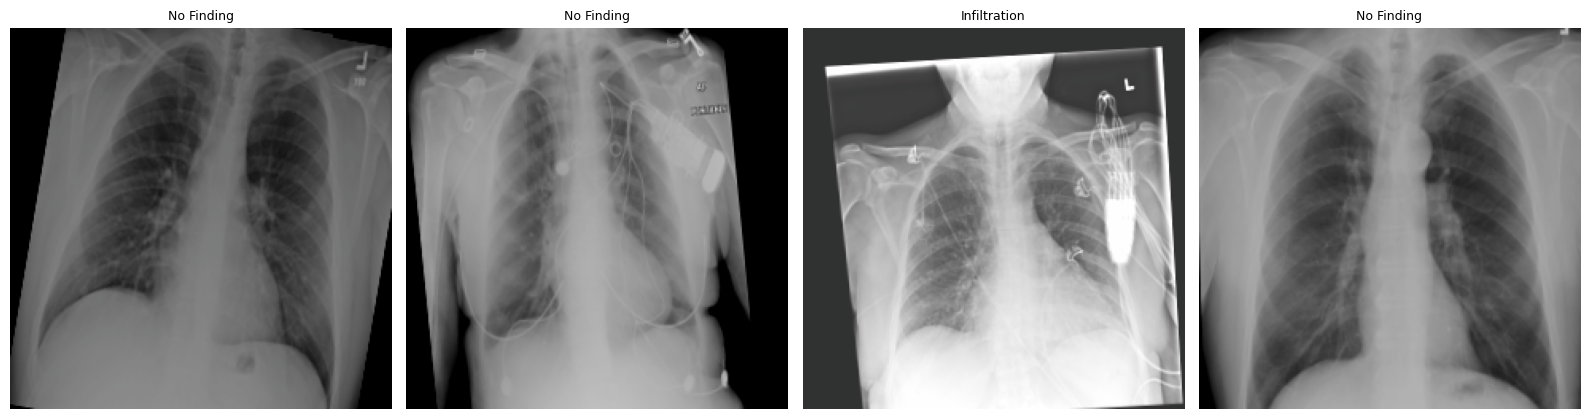

image: (3, 240, 240) torch.float32 range [-2.12, 1.16]
label: (14,) torch.float32


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
mean, std = np.array(IMAGENET_MEAN), np.array(IMAGENET_STD)

for ax, idx in zip(axes, np.random.randint(0, len(datasets["train"]), 4)):
    x, y = datasets["train"][int(idx)]
    ax.imshow(np.clip(x.permute(1,2,0).numpy()*std + mean, 0, 1))
    names = [p for p, v in zip(PATHOLOGIES, y.numpy()) if v > 0]
    ax.set_title("\n".join(names) if names else "No Finding", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

x, y = datasets["train"][0]
print("image:", tuple(x.shape), x.dtype, f"range [{x.min():.2f}, {x.max():.2f}]")
print("label:", tuple(y.shape), y.dtype)

## Cell 13 · Model — unpruned B1 with BatchNorm repair

```
pixels -> [ EfficientNet-B1 ] -> (B,1280,8,8) -> GAP -> (B,1280) -> head -> 14 logits
```

**The BatchNorm repair matters.** timm's B1 checkpoints ship denormal `running_var`
(~1e-42, below float32's normal minimum of 1.2e-38) in a handful of channels. BatchNorm
divides by `sqrt(var)`, so `sqrt(9e-42) ≈ 3e-21` multiplies activations by ~10²⁰ and the
whole forward pass explodes. Those channels carry no information; resetting them to
identity is a no-op, and fine-tuning recomputes the statistics within one epoch.

**No sigmoid in `forward()`** — `BCEWithLogitsLoss` applies it internally with better
numerical stability. Adding one here would double-apply it.

In [13]:
class ChestXrayNet(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.backbone = timm.create_model(
            cfg.backbone, pretrained=cfg.pretrained,
            num_classes=0, global_pool="")

        n_fixed = 0
        for m in self.backbone.modules():
            if isinstance(m, nn.BatchNorm2d) and m.running_var is not None:
                bad = m.running_var < 1e-6
                if bad.any():
                    m.running_var.data[bad] = 1.0
                    m.running_mean.data[bad] = 0.0
                    n_fixed += int(bad.sum())
        print(f"repaired {n_fixed} denormal BatchNorm channels")

        n_feat = self.backbone.num_features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Dropout(cfg.dropout),
            nn.Linear(n_feat, cfg.head_dim_1),
            nn.BatchNorm1d(cfg.head_dim_1),
            nn.ReLU(inplace=True),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.head_dim_1, cfg.head_dim_2),
            nn.ReLU(inplace=True),
            nn.Linear(cfg.head_dim_2, N_CLASSES),
        )

    def forward(self, x):
        f = self.backbone(x)
        return self.head(self.pool(f).flatten(1))


model = ChestXrayNet(cfg).to(device)

tot = sum(p.numel() for p in model.parameters())
bb  = sum(p.numel() for p in model.backbone.parameters())
print(f"backbone : {bb/1e6:6.2f} M   (pruned B1 was ~5.4M - this is the real one)")
print(f"head     : {(tot-bb)/1e6:6.2f} M")
print(f"total    : {tot/1e6:6.2f} M")

model.eval()          # CRITICAL: train mode would update BN running stats
with torch.no_grad():  # from this all-zeros batch and undo the repair above
    fm = model.backbone(torch.zeros(2, 3, cfg.img_size, cfg.img_size, device=device))
print("feature map:", tuple(fm.shape))

model.safetensors:   0%|          | 0.00/31.5M [00:00<?, ?B/s]

repaired 14 denormal BatchNorm channels
backbone :   6.51 M   (pruned B1 was ~5.4M - this is the real one)
head     :   0.79 M
total    :   7.31 M
feature map: (2, 1280, 8, 8)


## Cell 14 · Loss, optimizer, scheduler

**Discriminative learning rates.** The backbone arrived pretrained and needs gentle
nudging; the head started random and needs to move fast. Giving both the same LR
over-disturbs the backbone — that's what made v1 overfit at epoch 3.

**Cosine annealing** decays the LR smoothly to 1e-7 across all epochs. Without a schedule
the model keeps taking full-size steps after reaching a good region and bounces past it
into memorisation.

In [14]:
if cfg.pos_weight:
    pos = parts["train"][PATHOLOGIES].sum().to_numpy()
    w = torch.tensor((len(parts["train"])-pos)/np.maximum(pos,1),
                     dtype=torch.float32, device=device).clamp(max=50.)
    criterion = nn.BCEWithLogitsLoss(pos_weight=w)
    print(f"weighted BCE [{w.min():.1f}, {w.max():.1f}]")
else:
    criterion = nn.BCEWithLogitsLoss()
    print("plain BCE (paper-faithful)")

optimizer = torch.optim.AdamW([
    {"params": list(model.backbone.parameters()), "lr": cfg.backbone_lr},
    {"params": list(model.pool.parameters()) + list(model.head.parameters()),
     "lr": cfg.head_lr},
], weight_decay=cfg.weight_decay)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=cfg.epochs, eta_min=cfg.scheduler_eta_min)

scaler = torch.amp.GradScaler("cuda", enabled=cfg.amp)

print(f"AdamW | backbone {cfg.backbone_lr:.0e} head {cfg.head_lr:.0e} "
      f"| wd {cfg.weight_decay:.0e} | cosine T_max={cfg.epochs}")

plain BCE (paper-faithful)
AdamW | backbone 1e-05 head 5e-04 | wd 1e-04 | cosine T_max=30


## Cell 15 · Metrics + train/eval loops

AUC is computed **per disease**, then plain-averaged. Each disease counts equally —
Hernia (0.20% of data) weighs the same as Infiltration (17.7%).

In [15]:
def per_label_auc(y_true, y_prob):
    return {n: (float("nan") if y_true[:, i].min() == y_true[:, i].max()
                else roc_auc_score(y_true[:, i], y_prob[:, i]))
            for i, n in enumerate(PATHOLOGIES)}


def print_auc_table(aucs):
    print(f"\n  {'label':<20}{'yours':>8}{'paper':>8}{'delta':>8}")
    print("  " + "-"*44)
    for n in PATHOLOGIES:
        d = aucs[n] - PAPER_AUC[n]
        print(f"  {n:<20}{aucs[n]:>8.3f}{PAPER_AUC[n]:>8.3f}{d:>+8.3f}"
              f"{'  ahead' if d > 0 else ''}")
    m = float(np.nanmean(list(aucs.values())))
    print("  " + "-"*44)
    print(f"  {'MEAN':<20}{m:>8.3f}{PAPER_MEAN_AUC:>8.3f}{m-PAPER_MEAN_AUC:>+8.3f}\n")


def train_one_epoch(epoch, max_steps=None):
    model.train()
    running, seen, t0 = 0.0, 0, time.time()
    for step, (x, y) in enumerate(loaders["train"]):
        x = x.to(device, non_blocking=True); y = y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast("cuda", dtype=torch.float16, enabled=cfg.amp):
            loss = criterion(model(x), y)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        running += loss.item()*x.size(0); seen += x.size(0)
        if step % 100 == 0:
            print(f"  e{epoch} {step:>5}/{len(loaders['train'])}  "
                  f"loss {running/seen:.4f}  {seen/max(time.time()-t0,1e-9):.0f} img/s",
                  flush=True)
        if max_steps and step >= max_steps:
            break
    return running/max(seen, 1)


@torch.no_grad()
def evaluate(split, max_steps=None, return_raw=False):
    model.eval()
    running, seen, probs, trues = 0.0, 0, [], []
    for step, (x, y) in enumerate(loaders[split]):
        x = x.to(device, non_blocking=True); y = y.to(device, non_blocking=True)
        with torch.autocast("cuda", dtype=torch.float16, enabled=cfg.amp):
            logits = model(x); loss = criterion(logits, y)
        running += loss.item()*x.size(0); seen += x.size(0)
        probs.append(torch.sigmoid(logits.float()).cpu().numpy())
        trues.append(y.cpu().numpy())
        if max_steps and step >= max_steps:
            break
    y_prob, y_true = np.concatenate(probs), np.concatenate(trues)
    aucs = per_label_auc(y_true, y_prob)
    m = float(np.nanmean(list(aucs.values())))
    return (running/max(seen,1), m, aucs, y_true, y_prob) if return_raw \
           else (running/max(seen,1), m, aucs)

print("metrics + loops ready")

metrics + loops ready


## Cell 16 · The 0.69 gate

An untrained network outputs logits near zero → sigmoid gives ≈0.5 → BCE of a 0.5
prediction is `-ln(0.5) = 0.6931`.

| Reading | Meaning |
|---|---|
| **≈ 0.69** | labels, loss, shapes all correct → proceed |
| ≈ 5.0 | double sigmoid |
| ≈ 0.01 | targets all zero |
| huge | BatchNorm repair failed |

**Read the logit range, not the sigmoid mean.** Saturated logits (±10⁹) still average to
~0.5 after sigmoid, which hides catastrophic failures behind a reasonable-looking number.

In [16]:
model.eval()
xb, yb = next(iter(loaders["train"]))
xb, yb = xb.to(device), yb.to(device)
with torch.no_grad():
    lg = model(xb); l0 = nn.BCEWithLogitsLoss()(lg, yb)

print("batch     :", tuple(xb.shape))
print("logits    :", tuple(lg.shape))
print("logit rng :", f"[{lg.min():.3f}, {lg.max():.3f}]   <-- must be small")
print("mean sigm :", f"{torch.sigmoid(lg).mean():.3f}")
print(f"\nINITIAL LOSS: {l0.item():.4f}   <-- expect ~0.6931")
print("\nPASSED" if abs(l0.item()-0.693) < 0.15 and lg.abs().max() < 100
      else "\nFAILED - stop and debug")

batch     : (40, 3, 240, 240)
logits    : (40, 14)
logit rng : [-0.102, 0.076]   <-- must be small
mean sigm : 0.492

INITIAL LOSS: 0.6786   <-- expect ~0.6931

PASSED


## Cell 17 · Crash recovery

Kaggle wipes `/kaggle/working/` when a session terminates, and interactive sessions die
~20–40 min after you close the tab. This cell rebuilds training state from `last.pt`
if it exists.

**What gets saved each epoch:**

| File | Contents |
|---|---|
| `best.pt` | weights from the best-val-AUC epoch |
| `last.pt` | weights + optimizer + scaler + history (full resume state) |
| `best_params.txt` | human-readable config, metrics, and resume instructions |
| `history.csv` | per-epoch losses and all 14 AUCs |

Weights are 6.5M floats — they can't live in a text file. `best_params.txt` holds
everything needed to *reconstruct* the run; `best.pt` holds the weights themselves.

**For real protection against power loss, use Save Version → Save & Run All.** That runs
server-side, independent of your browser, and persists outputs automatically.

In [17]:
ckpt_best, ckpt_last = OUT / "best.pt", OUT / "last.pt"
txt_params = OUT / "best_params.txt"

def write_params_txt(epoch, best_auc, best_epoch, aucs, extra=""):
    lines = [
        "ChestX-ray14 / EfficientNet-B1 replication - run state",
        "="*60, "",
        f"last completed epoch : {epoch}",
        f"best val mean AUC    : {best_auc:.4f} @ epoch {best_epoch}",
        f"paper target         : {PAPER_MEAN_AUC:.4f}",
        f"gap                  : {best_auc-PAPER_MEAN_AUC:+.4f}", "",
        "per-label val AUC at best epoch", "-"*60,
    ]
    for n in PATHOLOGIES:
        lines.append(f"  {n:<22}{aucs.get(n, float('nan')):.4f}   "
                     f"(paper {PAPER_AUC[n]:.3f})")
    lines += ["", "config", "-"*60]
    for k, v in asdict(cfg).items():
        lines.append(f"  {k:<22}{v}")
    lines += ["", "resume", "-"*60,
              "  1. run cells 1-15 (cell 9 skips already-cached images)",
              "  2. run this cell - it auto-loads last.pt",
              "  3. run cell 18",
              "", extra]
    txt_params.write_text("\n".join(lines))


start_epoch, best_auc, best_epoch, since_improve, history = 0, -1.0, -1, 0, []

if ckpt_last.exists():
    st = torch.load(ckpt_last, map_location=device)
    model.load_state_dict(st["model"])
    optimizer.load_state_dict(st["optimizer"])
    scaler.load_state_dict(st["scaler"])
    start_epoch   = st["epoch"] + 1
    best_auc      = st["best_auc"]
    best_epoch    = st["best_epoch"]
    since_improve = st["since_improve"]
    history       = st["history"]
    for _ in range(start_epoch):
        scheduler.step()                      # fast-forward the LR schedule
    print(f"RESUMING at epoch {start_epoch} | best {best_auc:.4f} @ epoch {best_epoch}")
    print("lr now:", [f"{g['lr']:.2e}" for g in optimizer.param_groups])
else:
    print("fresh start at epoch 0")

fresh start at epoch 0


## Cell 18 · Training  *(~3 hours)*

Two callbacks, as the paper describes:

- **ModelCheckpoint** — saves whenever val mean AUC hits a new high
- **EarlyStopping** — halts after **7** consecutive epochs with no improvement

**Watch epoch 0:** val mean AUC should land around 0.78–0.80. That's transfer learning
working. Around 0.52 means the ImageNet weights aren't loaded.

**Watch the divergence:** val *loss* often starts rising while val *AUC* keeps climbing.
That's normal — the model gets more confident (hurting BCE) while still ranking better
(helping AUC). AUC is what you're optimising. v1 peaked at AUC epoch 5 with val loss
rising from epoch 4.

In [18]:
for epoch in range(start_epoch, cfg.epochs):
    print(f"\n{'='*56}\nEPOCH {epoch}/{cfg.epochs-1}\n{'='*56}")

    tr_loss               = train_one_epoch(epoch)
    va_loss, va_auc, aucs = evaluate("val")

    lrs = [f"{g['lr']:.2e}" for g in optimizer.param_groups]
    print(f"\n  train {tr_loss:.4f} | val {va_loss:.4f} | "
          f"val mean AUC {va_auc:.4f} | lr {lrs}")
    print_auc_table(aucs)

    history.append({"epoch": epoch, "train_loss": tr_loss, "val_loss": va_loss,
                    "val_mean_auc": va_auc, "lr_backbone": optimizer.param_groups[0]["lr"],
                    **{f"auc_{k}": v for k, v in aucs.items()}})
    pd.DataFrame(history).to_csv(OUT / "history.csv", index=False)

    if va_auc > best_auc:
        best_auc, best_epoch, since_improve = va_auc, epoch, 0
        torch.save({"model": model.state_dict(), "epoch": epoch,
                    "val_mean_auc": va_auc, "cfg": asdict(cfg)}, ckpt_best)
        write_params_txt(epoch, best_auc, best_epoch, aucs)
        print(f"  [ckpt] NEW BEST {va_auc:.4f}")
    else:
        since_improve += 1
        print(f"  [ckpt] no gain ({since_improve}/{cfg.patience}) | "
              f"best {best_auc:.4f} @ epoch {best_epoch}")

    torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(),
                "scaler": scaler.state_dict(), "epoch": epoch, "best_auc": best_auc,
                "best_epoch": best_epoch, "since_improve": since_improve,
                "history": history}, ckpt_last)

    scheduler.step()

    if since_improve >= cfg.patience:
        print(f"\n[EARLY STOP] no gain for {cfg.patience} epochs. "
              f"Best {best_auc:.4f} @ epoch {best_epoch}")
        break

print(f"\nDONE. best val mean AUC = {best_auc:.4f} @ epoch {best_epoch}")


EPOCH 0/29
  e0     0/1954  loss 0.6705  1 img/s
  e0   100/1954  loss 0.2159  53 img/s
  e0   200/1954  loss 0.1983  87 img/s
  e0   300/1954  loss 0.1913  110 img/s
  e0   400/1954  loss 0.1867  126 img/s
  e0   500/1954  loss 0.1851  138 img/s
  e0   600/1954  loss 0.1842  148 img/s
  e0   700/1954  loss 0.1832  155 img/s
  e0   800/1954  loss 0.1823  161 img/s
  e0   900/1954  loss 0.1808  166 img/s
  e0  1000/1954  loss 0.1795  171 img/s
  e0  1100/1954  loss 0.1790  175 img/s
  e0  1200/1954  loss 0.1781  178 img/s
  e0  1300/1954  loss 0.1773  181 img/s
  e0  1400/1954  loss 0.1770  183 img/s
  e0  1500/1954  loss 0.1767  185 img/s
  e0  1600/1954  loss 0.1762  187 img/s
  e0  1700/1954  loss 0.1761  189 img/s
  e0  1800/1954  loss 0.1759  191 img/s
  e0  1900/1954  loss 0.1755  192 img/s

  train 0.1753 | val 0.1656 | val mean AUC 0.7526 | lr ['1.00e-05', '5.00e-04']

  label                  yours   paper   delta
  --------------------------------------------
  Atelectasis   

## Cell 19 · Final test evaluation

The test split has never been touched — not for gradients, not for checkpoint selection.
This is the honest number.

**0.82–0.85 is a successful replication.** Above 0.88 should make you suspicious rather
than pleased — go re-check the leakage guard.

In [19]:
model.load_state_dict(torch.load(ckpt_best, map_location=device)["model"])
te_loss, te_auc, te_aucs, Y_TRUE, Y_PROB = evaluate("test", return_raw=True)

print(f"test loss {te_loss:.4f} | TEST MEAN AUC {te_auc:.4f}")
print_auc_table(te_aucs)

n_pos = parts["test"][PATHOLOGIES].sum()
reliable = [p for p in PATHOLOGIES if n_pos[p] >= 100]
if reliable:
    print(f"\nmean AUC over {len(reliable)} labels with >=100 test positives: "
          f"{np.mean([te_aucs[p] for p in reliable]):.4f}")
    print(f"excluded as statistically unreliable: "
          f"{[(p, int(n_pos[p])) for p in PATHOLOGIES if p not in reliable]}")
else:
    print("\nno label has >=100 test positives (unexpected on the full dataset)")

write_params_txt(best_epoch, best_auc, best_epoch, te_aucs,
                 extra=f"FINAL TEST MEAN AUC: {te_auc:.4f}")

test loss 0.1505 | TEST MEAN AUC 0.8182

  label                  yours   paper   delta
  --------------------------------------------
  Atelectasis            0.794   0.817  -0.023
  Cardiomegaly           0.893   0.911  -0.018
  Effusion               0.879   0.879  -0.000
  Infiltration           0.698   0.716  -0.018
  Mass                   0.817   0.853  -0.036
  Nodule                 0.755   0.771  -0.016
  Pneumonia              0.743   0.769  -0.026
  Pneumothorax           0.879   0.898  -0.019
  Consolidation          0.779   0.815  -0.036
  Edema                  0.901   0.908  -0.007
  Emphysema              0.900   0.935  -0.035
  Fibrosis               0.791   0.824  -0.033
  Pleural_Thickening     0.778   0.812  -0.034
  Hernia                 0.848   0.890  -0.042
  --------------------------------------------
  MEAN                   0.818   0.843  -0.025


mean AUC over 13 labels with >=100 test positives: 0.8159
excluded as statistically unreliable: [('Hernia', 46)

## Cell 20 · ROC curves — the paper's Figure 2

True positive rate against false positive rate, one curve per disease.

**How to read it:** the diagonal is random guessing. The further a curve bows toward the
top-left, the better that disease is being detected. AUC is literally the area under each
curve — the single number summarising the whole thing.

Expect Emphysema, Cardiomegaly, and Edema hugging the top-left; Infiltration and Pneumonia
sagging toward the diagonal.

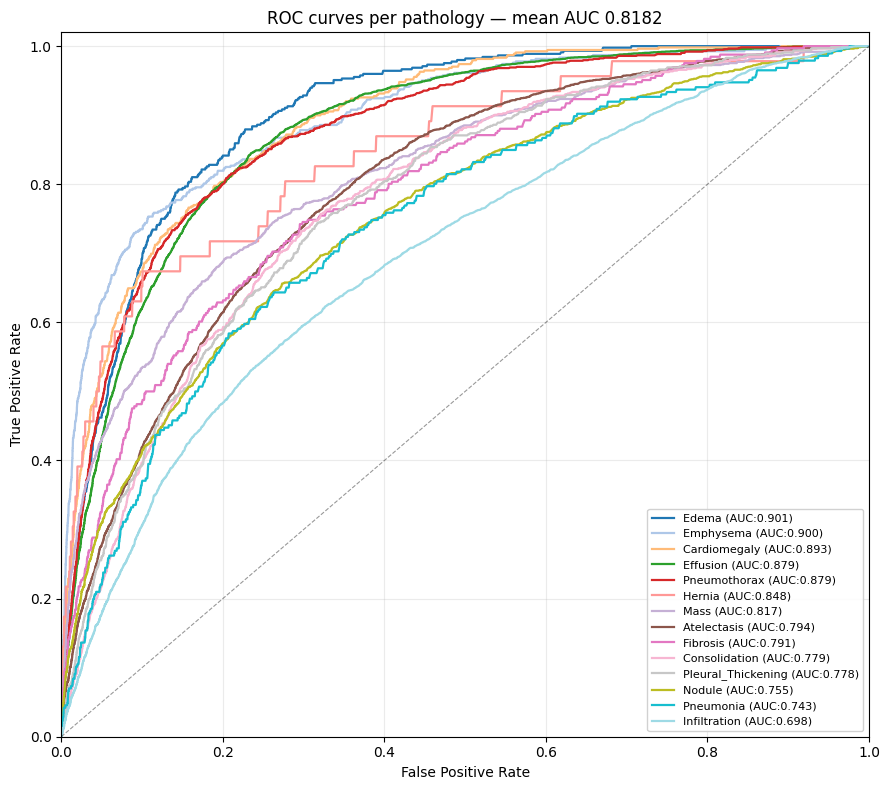

In [20]:
fig, ax = plt.subplots(figsize=(9, 8))
order = sorted(PATHOLOGIES, key=lambda p: -te_aucs[p])
cmap  = plt.cm.tab20(np.linspace(0, 1, 14))

for c, name in zip(cmap, order):
    i = PATHOLOGIES.index(name)
    fpr, tpr, _ = roc_curve(Y_TRUE[:, i], Y_PROB[:, i])
    ax.plot(fpr, tpr, color=c, lw=1.6,
            label=f"{name} (AUC:{te_aucs[name]:.3f})")

ax.plot([0,1], [0,1], "k--", lw=0.8, alpha=0.4)
ax.set(xlim=(0,1), ylim=(0,1.02),
       xlabel="False Positive Rate", ylabel="True Positive Rate",
       title=f"ROC curves per pathology — mean AUC {te_auc:.4f}")
ax.legend(loc="lower right", fontsize=8, framealpha=0.9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUT / "roc_curves.png", dpi=150)
plt.show()

## Cell 21 · Extended metrics — beyond what the paper reports

The paper gives AUC only. AUC is threshold-free, which is elegant but hides how the model
would behave if you actually deployed it. These metrics answer "what if we had to commit
to a decision?"

| Metric | What it tells you |
|---|---|
| **Sensitivity** (recall) | of patients who have it, what fraction do we catch? |
| **Specificity** | of healthy patients, what fraction do we correctly clear? |
| **Precision** (PPV) | when we say positive, how often are we right? |
| **F1** | harmonic mean of precision and recall |
| **AUPRC** | area under precision-recall — far more honest than AUC on rare classes |
| **Youden J** | sensitivity + specificity − 1, maximised to pick the threshold |

**Why AUPRC matters here.** With Hernia at 0.20% prevalence, a model can have AUC 0.90 and
still be nearly useless in practice — most of its positive predictions are wrong. AUPRC
exposes that; AUC doesn't. Compare the two columns for the rare labels.

In [21]:
rows = []
for i, name in enumerate(PATHOLOGIES):
    yt, yp = Y_TRUE[:, i], Y_PROB[:, i]
    if yt.min() == yt.max():          # no positives (or no negatives) in test
        print(f"  skipping {name}: no positive cases in test split")
        continue
    fpr, tpr, thr = roc_curve(yt, yp)
    j = np.argmax(tpr - fpr)                     # Youden's J
    t_opt = thr[j]
    pred = (yp >= t_opt).astype(int)

    tp = int(((pred==1) & (yt==1)).sum()); fn = int(((pred==0) & (yt==1)).sum())
    tn = int(((pred==0) & (yt==0)).sum()); fp = int(((pred==1) & (yt==0)).sum())
    prec, rec, f1, _ = precision_recall_fscore_support(
        yt, pred, average="binary", zero_division=0)

    rows.append({
        "label": name, "n_pos": int(yt.sum()),
        "AUC": te_aucs[name], "AUPRC": average_precision_score(yt, yp),
        "thresh": t_opt, "sens": rec, "spec": tn/max(tn+fp, 1),
        "prec": prec, "F1": f1, "youden_J": tpr[j]-fpr[j],
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
    })

met = pd.DataFrame(rows)
met.to_csv(OUT / "extended_metrics.csv", index=False)

print(met[["label","n_pos","AUC","AUPRC","sens","spec","prec","F1"]]
      .to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print(f"\nmacro AUC   {met.AUC.mean():.4f}")
print(f"macro AUPRC {met.AUPRC.mean():.4f}   <-- much lower; that's the imbalance talking")
print(f"macro F1    {met.F1.mean():.4f}")

             label  n_pos   AUC  AUPRC  sens  spec  prec    F1
       Atelectasis   2339 0.794  0.319 0.760 0.684 0.216 0.336
      Cardiomegaly    539 0.893  0.246 0.766 0.842 0.105 0.185
          Effusion   2824 0.879  0.511 0.845 0.765 0.337 0.482
      Infiltration   4071 0.698  0.337 0.568 0.729 0.313 0.404
              Mass   1098 0.817  0.293 0.692 0.798 0.148 0.243
            Nodule   1376 0.755  0.229 0.656 0.727 0.134 0.222
         Pneumonia    286 0.743  0.042 0.643 0.737 0.030 0.058
      Pneumothorax   1133 0.879  0.309 0.816 0.790 0.169 0.280
     Consolidation    905 0.779  0.123 0.757 0.679 0.089 0.159
             Edema    448 0.901  0.172 0.879 0.772 0.072 0.133
         Emphysema    543 0.900  0.333 0.753 0.892 0.146 0.244
          Fibrosis    326 0.791  0.091 0.742 0.705 0.035 0.067
Pleural_Thickening    650 0.778  0.102 0.745 0.682 0.064 0.118
            Hernia     46 0.848  0.050 0.674 0.899 0.013 0.026

macro AUC   0.8182
macro AUPRC 0.2256   <-- much lower

## Cell 22 · Training curves and comparisons

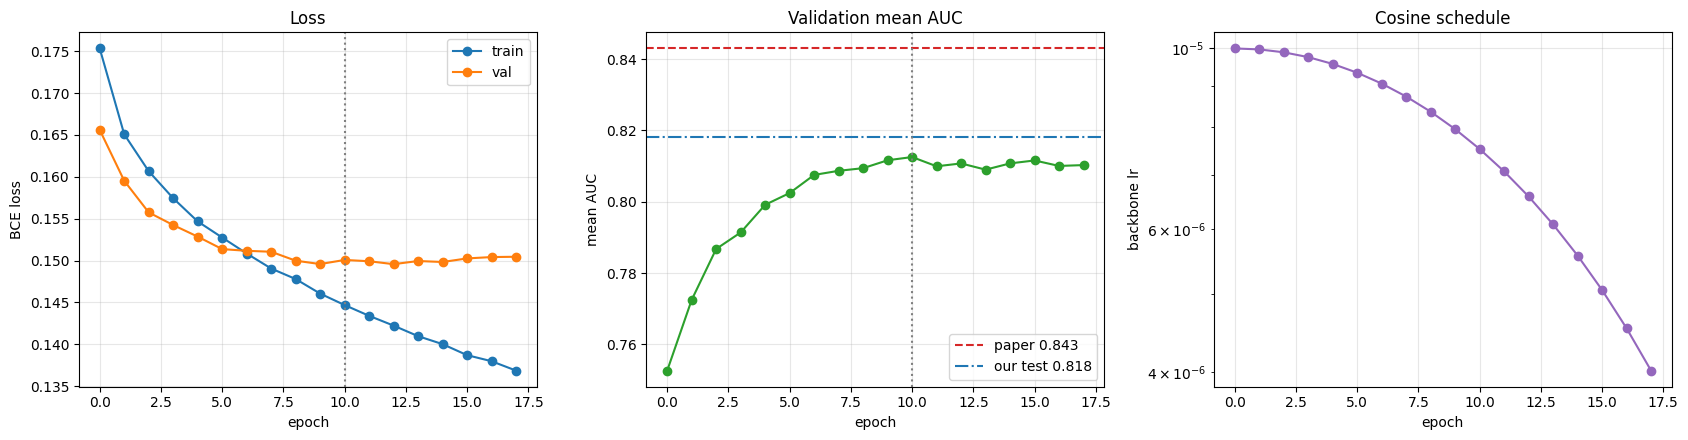

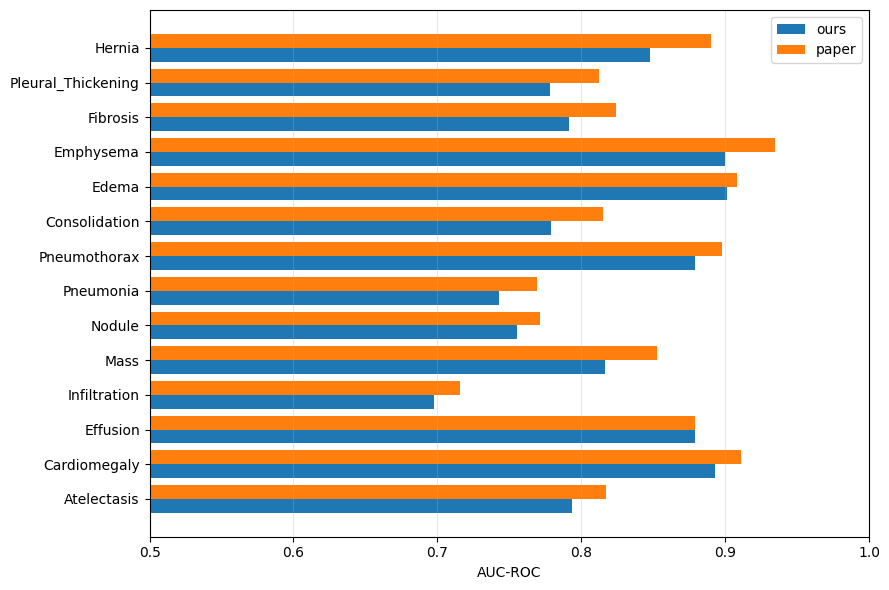

In [22]:
h = pd.DataFrame(history)
if h.empty:
    print("history is empty (run resumed past the final epoch) - "
          "reload it with: history = torch.load(ckpt_last)['history']")
    h = pd.DataFrame(torch.load(ckpt_last, map_location="cpu")["history"])

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))

ax[0].plot(h.epoch, h.train_loss, "o-", label="train")
ax[0].plot(h.epoch, h.val_loss, "o-", label="val")
ax[0].axvline(best_epoch, ls=":", c="grey")
ax[0].set(xlabel="epoch", ylabel="BCE loss", title="Loss")
ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(h.epoch, h.val_mean_auc, "o-", c="tab:green")
ax[1].axhline(PAPER_MEAN_AUC, ls="--", c="tab:red", label=f"paper {PAPER_MEAN_AUC}")
ax[1].axhline(te_auc, ls="-.", c="tab:blue", label=f"our test {te_auc:.3f}")
ax[1].axvline(best_epoch, ls=":", c="grey")
ax[1].set(xlabel="epoch", ylabel="mean AUC", title="Validation mean AUC")
ax[1].legend(); ax[1].grid(alpha=.3)

ax[2].plot(h.epoch, h.lr_backbone, "o-", c="tab:purple")
ax[2].set(xlabel="epoch", ylabel="backbone lr", title="Cosine schedule", yscale="log")
ax[2].grid(alpha=.3)
plt.tight_layout(); plt.savefig(OUT / "curves.png", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(PATHOLOGIES))
ax.barh(y-0.2, [te_aucs[p] for p in PATHOLOGIES], 0.4, label="ours")
ax.barh(y+0.2, [PAPER_AUC[p] for p in PATHOLOGIES], 0.4, label="paper")
ax.set_yticks(y); ax.set_yticklabels(PATHOLOGIES)
ax.set_xlim(0.5, 1.0); ax.set_xlabel("AUC-ROC")
ax.legend(); ax.grid(alpha=.3, axis="x")
plt.tight_layout(); plt.savefig(OUT / "auc_comparison.png", dpi=150); plt.show()

## Cell 23 · Grad-CAM — the paper's Figure 3

Gradient-weighted Class Activation Mapping shows *where* the model looked when it made a
prediction. It works by taking the gradient of a class score with respect to the final
convolutional feature map, average-pooling those gradients into per-channel weights, and
summing the weighted channels.

This is the model's own explanation of its decision — worth checking, because a model can
reach a good AUC by latching onto artefacts (text markers, tubes, scanner borders) rather
than pathology.

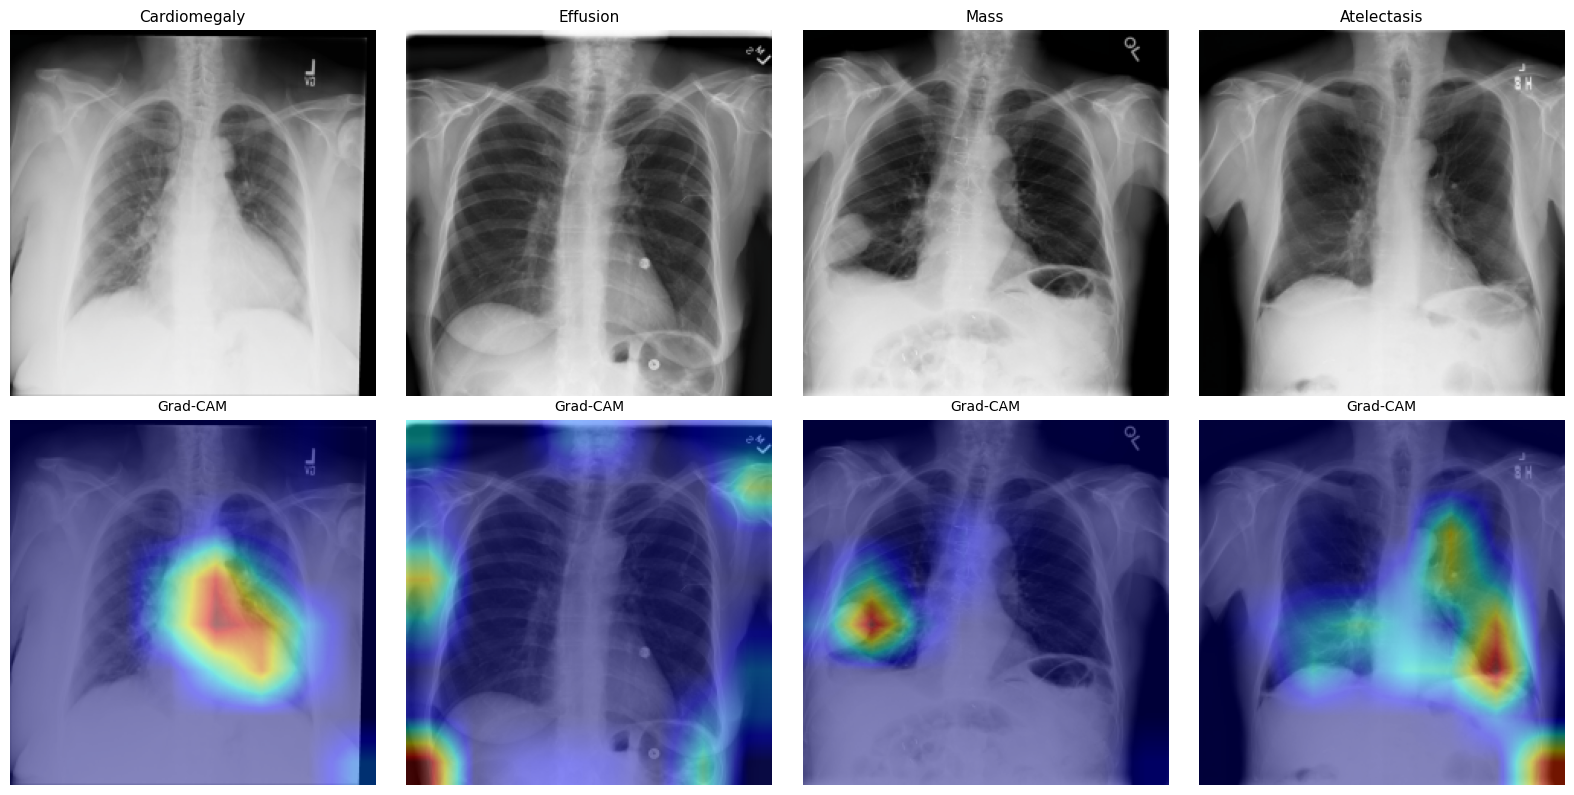

In [23]:
def grad_cam(model, x, class_idx):
    """Gradient-weighted Class Activation Mapping.

    One backward pass only: torch.autograd.grad() computes the gradient of the
    class logit w.r.t. the backbone feature map directly. Calling .backward()
    first would free the graph and make this fail.
    """
    model.eval()
    feats = {}
    handle = model.backbone.register_forward_hook(lambda m, i, o: feats.update(a=o))

    logits = model(x.unsqueeze(0).to(device))
    handle.remove()

    A = feats["a"]                                       # (1, C, H, W)
    g = torch.autograd.grad(logits[0, class_idx], A)[0]

    w   = g.mean(dim=(2, 3), keepdim=True)               # channel importance
    cam = F.relu((w * A).sum(1, keepdim=True))
    cam = F.interpolate(cam, size=(cfg.img_size, cfg.img_size),
                        mode="bilinear", align_corners=False)
    cam = cam[0, 0].detach().cpu().numpy()
    return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)


show = ["Cardiomegaly", "Effusion", "Mass", "Atelectasis"]
fig, axes = plt.subplots(2, len(show), figsize=(4*len(show), 8))
mean, std = np.array(IMAGENET_MEAN), np.array(IMAGENET_STD)

for col, name in enumerate(show):
    ci  = PATHOLOGIES.index(name)
    hit = parts["test"].index[parts["test"][name] == 1]
    if len(hit) == 0:
        axes[0, col].axis("off"); axes[1, col].axis("off")
        continue
    x, _ = datasets["test"][int(hit[0])]
    img  = np.clip(x.permute(1, 2, 0).numpy()*std + mean, 0, 1)
    cam  = grad_cam(model, x, ci)

    axes[0, col].imshow(img);  axes[0, col].set_title(name, fontsize=11)
    axes[1, col].imshow(img);  axes[1, col].imshow(cam, cmap="jet", alpha=0.45)
    axes[1, col].set_title("Grad-CAM", fontsize=10)
    axes[0, col].axis("off");  axes[1, col].axis("off")

plt.tight_layout(); plt.savefig(OUT / "gradcam.png", dpi=150); plt.show()

## Cell 24 · Save everything

Writes a final summary and lists all artifacts. **Commit the notebook (Save Version) to
persist `/kaggle/working/` — otherwise it's wiped when the session ends.**

In [24]:
summary = {
    "test_mean_auc": round(te_auc, 4),
    "paper_mean_auc": PAPER_MEAN_AUC,
    "gap": round(te_auc - PAPER_MEAN_AUC, 4),
    "best_val_auc": round(best_auc, 4),
    "best_epoch": best_epoch,
    "epochs_run": len(history),
    "backbone": cfg.backbone,
    "img_size": cfg.img_size,
    "split_seed": cfg.split_seed,
    "per_label_test_auc": {k: round(v, 4) for k, v in te_aucs.items()},
    "macro_auprc": round(met.AUPRC.mean(), 4),
    "macro_f1": round(met.F1.mean(), 4),
}
(OUT / "summary.json").write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))

# The ~4 GB image cache would otherwise be saved as notebook output on commit.
# It regenerates in ~15 min; the checkpoints and metrics do not.
shutil.rmtree(cfg.cache_root, ignore_errors=True)
print("image cache deleted\n")

print("artifacts kept:")
for f in sorted(OUT.iterdir()):
    print(f"  {f.name:<24}{f.stat().st_size/1e6:>8.2f} MB")

{
  "test_mean_auc": 0.8182,
  "paper_mean_auc": 0.843,
  "gap": -0.0248,
  "best_val_auc": 0.8125,
  "best_epoch": 10,
  "epochs_run": 18,
  "backbone": "tf_efficientnet_b1.ns_jft_in1k",
  "img_size": 240,
  "split_seed": 97,
  "per_label_test_auc": {
    "Atelectasis": 0.7936,
    "Cardiomegaly": 0.8928,
    "Effusion": 0.8789,
    "Infiltration": 0.6976,
    "Mass": 0.8165,
    "Nodule": 0.7554,
    "Pneumonia": 0.7431,
    "Pneumothorax": 0.8787,
    "Consolidation": 0.7789,
    "Edema": 0.9011,
    "Emphysema": 0.9001,
    "Fibrosis": 0.7915,
    "Pleural_Thickening": 0.7784,
    "Hernia": 0.8477
  },
  "macro_auprc": 0.2256,
  "macro_f1": 0.2112
}
image cache deleted

artifacts kept:
  auc_comparison.png          0.05 MB
  best.pt                    29.64 MB
  best_params.txt             0.00 MB
  config.json                 0.00 MB
  curves.png                  0.13 MB
  extended_metrics.csv        0.00 MB
  gradcam.png                 1.37 MB
  history.csv                 0.01 